# 01 — Exploratory Data Analysis

**Dataset:** Rossmann Store Sales — daily sales for 1,115 drug stores across
Germany, 2013-01-01 to 2015-07-31 (public Kaggle dataset). This notebook
establishes the baseline patterns before any forecasting: seasonality,
promotion effects, and store-type differences.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/sales_clean.csv", low_memory=False, parse_dates=["Date"])
df.shape

(844392, 18)

In [2]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Day-of-week seasonality

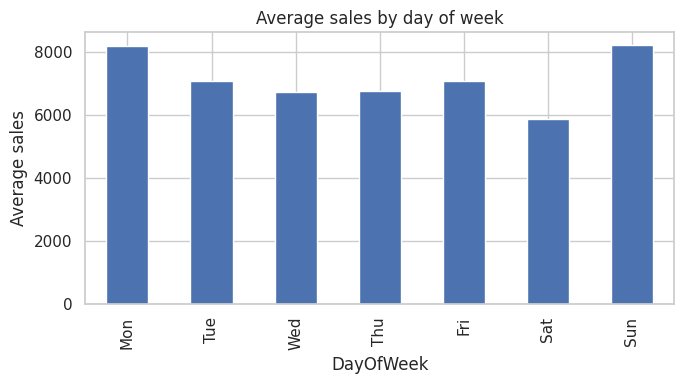

In [3]:
dow_names = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
dow = df.groupby("DayOfWeek")["Sales"].mean().rename(index=dow_names)

fig, ax = plt.subplots(figsize=(7,4))
dow.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_ylabel("Average sales")
ax.set_title("Average sales by day of week")
plt.tight_layout()
plt.savefig("../reports/01_day_of_week.png", dpi=120)
plt.show()

## Promotion effect, by store type

In [4]:
promo_effect = df.groupby(["StoreType","Promo"])["Sales"].mean().unstack()
promo_effect.columns = ["No promo","Promo"]
promo_effect["lift_pct"] = (promo_effect["Promo"] / promo_effect["No promo"] - 1) * 100
promo_effect.round(1)

,No promo,Promo,lift_pct
StoreType,,,
a,5808.5,8304.1,43.0
b,9566.9,11308.0,18.2
c,6028.1,8042.0,33.4
d,5855.3,8017.8,36.9


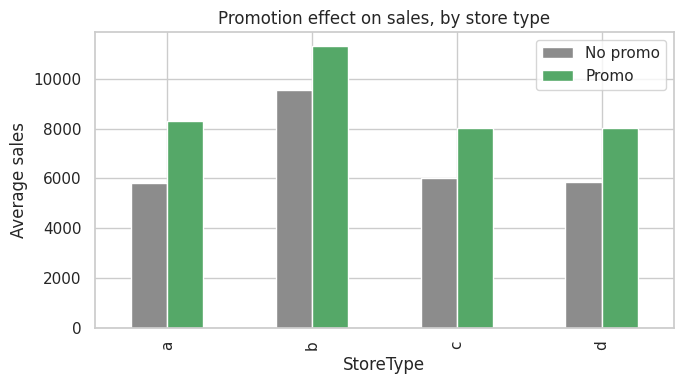

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
promo_effect[["No promo","Promo"]].plot(kind="bar", ax=ax, color=["#8c8c8c","#55a868"])
ax.set_ylabel("Average sales")
ax.set_title("Promotion effect on sales, by store type")
plt.tight_layout()
plt.savefig("../reports/01_promo_effect.png", dpi=120)
plt.show()

**Reading this:** promotions lift average sales meaningfully across every
store type, with the size of the lift varying by type — this is the kind
of effect a forecasting model should be able to pick up on if promo flags
are included as a feature.


## Monthly trend (aggregate, all stores)

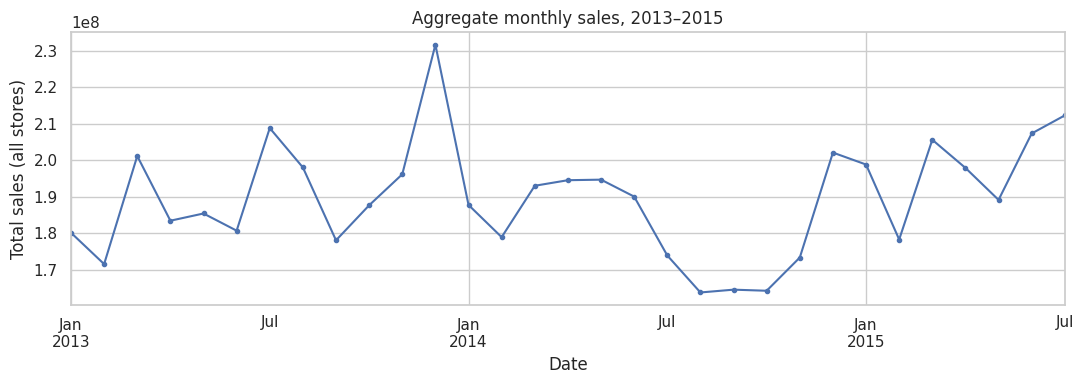

In [6]:
monthly = df.set_index("Date").resample("MS")["Sales"].sum()

fig, ax = plt.subplots(figsize=(11,4))
monthly.plot(ax=ax, color="#4c72b0", marker="o", markersize=3)
ax.set_ylabel("Total sales (all stores)")
ax.set_title("Aggregate monthly sales, 2013–2015")
plt.tight_layout()
plt.savefig("../reports/01_monthly_trend.png", dpi=120)
plt.show()

Clear annual seasonality is visible — a December spike (holiday shopping)
each year, and a dip in the summer months. This matters directly for
notebook 02: any forecasting method that ignores yearly seasonality will
systematically miss the December peak.

**Next:** `02_forecasting_comparison.ipynb` — ARIMA vs. Prophet vs.
Holt-Winters, evaluated on a single store's held-out final weeks.
